# Part1 Feature Extraction

In [1]:
import os
os.chdir('./proj1_data/')
os.getcwd()

'/home/tako/Kasetsart/statistics/project1/proj1_data'

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import statsmodels.api as sm

## Data

In [3]:
Dataset = "part1_cleaned.csv"
orig_df = pd.read_csv(Dataset)
orig_df

,Country Name,Year,Agricultural land (% of land area),"Agriculture, forestry, and fishing, value added (% of GDP)",Arable land (% of land area),Cereal yield (kg per hectare),Crop production index (2014-2016 = 100),Fertilizer consumption (kilograms per hectare of arable land),Food production index (2014-2016 = 100),Forest area (% of land area),...,High-technology exports (current US$),Medium and high-tech exports (% manufactured exports),Merchandise exports (current US$),Merchandise imports (current US$),Merchandise trade (% of GDP),"Contributing family workers, female (% of female employment) (modeled ILO estimate)","Contributing family workers, male (% of male employment) (modeled ILO estimate)",Gender Ratio Class,Region,ThirdWorld
0,Afghanistan,2021,58.74,33.60,12.00,2099.00,125.67,5.20,114.32,1.85,...,95210004.0,0.340000,8.500000e+08,5.308000e+09,43.16,60.87,12.79,1.0,South Asia,Yes
1,Albania,2021,41.47,18.36,21.89,5144.70,114.68,92.20,104.92,28.79,...,6384226.0,8.410000,3.559000e+09,7.718000e+09,62.89,27.58,15.96,1.0,Eastern Europe,No
2,Algeria,2021,17.35,11.23,3.16,1433.70,108.76,20.68,104.83,0.82,...,95210004.0,3.950000,3.863700e+10,3.746600e+10,40.86,2.10,1.61,1.0,Africa,No
3,American Samoa,2021,14.50,6.56,4.85,3062.55,104.94,92.20,105.58,85.50,...,95210004.0,33.137748,3.100000e+08,8.840000e+08,159.20,3.60,1.81,2.0,Australia and Oceanea,No
4,Andorra,2021,39.91,0.53,1.59,3062.55,104.94,92.20,105.58,34.04,...,36063879.0,33.137748,1.640000e+08,1.563000e+09,51.94,3.60,1.81,2.0,Western Europe,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
211,Virgin Islands (U.S.),2021,9.43,6.56,2.57,3062.55,104.94,92.20,105.58,57.31,...,95210004.0,33.137748,8.031000e+09,1.002400e+10,57.73,0.34,0.21,5.0,North America,No
212,West Bank and Gaza,2021,64.93,6.32,6.95,2251.90,117.31,371.97,117.39,1.68,...,14531924.0,15.110000,8.031000e+09,1.002400e+10,57.73,8.55,3.44,5.0,Middle East,No
213,"Yemen, Rep.",2021,44.42,6.56,2.19,1524.80,124.71,10.63,120.77,1.04,...,95210004.0,0.250000,6.620000e+08,5.054000e+09,29.68,37.64,9.04,1.0,Middle East,Yes
214,Zambia,2021,32.07,3.00,5.11,2525.00,136.31,63.90,127.49,60.03,...,10218867.0,28.800000,1.010100e+10,6.435000e+09,74.84,4.87,2.36,5.0,Africa,Yes


In [4]:
df = orig_df.copy()
y = df['Gender Ratio Class']
X = df.select_dtypes(include=['number'])
X.drop(['Gender Ratio Class'], axis=1, inplace=True)

In [5]:
y.unique()

array([1., 2., 5., 4., 3.])

## LDA

In [6]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
selected_n_components = 4 # can be adjusted
lda = LinearDiscriminantAnalysis(n_components=selected_n_components)

X_lda = lda.fit_transform(X_scaled, y)

In [7]:
# How different variables contributes class separation
print("Discriminant coefficients (w):")
print(lda.scalings_)

Discriminant coefficients (w):
[[ 3.61676956e-11 -2.57301928e-12 -7.17420668e-12 -7.10254435e-11]
 [ 1.80711222e-01 -1.77554842e-01  2.78287738e-01 -1.62156177e-02]
 [ 1.45791263e-01 -6.39883542e-02  2.63982112e-01  3.31201869e-01]
 [-2.01406278e-01 -4.50114494e-02  2.45890997e-01  2.20812955e-01]
 [ 4.50552663e-01  2.11738204e-01 -9.41999700e-02  7.27186917e-02]
 [-3.76900772e-01 -7.64740615e-01 -7.13287598e-01  8.32196438e-02]
 [-1.34533687e-01  3.80630747e-02 -5.59537180e-03  1.17993322e-01]
 [ 6.46724016e-01  1.36337869e+00  8.36112166e-01 -5.38083423e-01]
 [-2.45139687e-02 -1.95871589e-01  8.66959188e-02  3.61523076e-01]
 [ 9.52920574e-01  1.96206906e-02 -7.50564126e-01 -4.81873671e-01]
 [-1.38208134e+00  1.47889932e+00 -1.01234532e-01  1.11488371e-01]
 [-1.29613860e-01 -6.46026578e-01 -3.44980439e-01  1.13253558e-01]
 [-9.69102864e-04  2.77746112e-01 -4.66947647e-01 -7.02927385e-02]
 [-1.39489761e+00 -2.52014030e+01 -1.52707369e+01 -7.98808447e+00]
 [-2.04675393e+00  5.20199314e-

In [8]:
# Interpret variable contribution to class separation
# Larger absolute value = stronger contribution to class separation
# Direction indicates which class side
# Compare coefficients within the same discriminant axis

scalings_df = pd.DataFrame(
    lda.scalings_,
    index=X.columns,
    columns=[f"LD{i+1}" for i in range(lda.scalings_.shape[1])]
)

scalings_df.abs().sort_values(by="LD1", ascending=False)

,LD1,LD2,LD3,LD4
Population ages 0-14 (% of total population),2.610472e+02,1.414244e+01,5.003966e+01,5.118772e+02
Population ages 65 and above (% of total population),1.737366e+02,9.951996e+00,3.306092e+01,3.388900e+02
Population ages 15-64 (% of total population),1.541726e+02,1.021099e+01,2.791157e+01,3.020499e+02
"Life expectancy at birth, total (years)",1.330122e+01,4.282236e+00,2.293020e-01,1.838793e+01
"Life expectancy at birth, female (years)",7.043647e+00,2.802609e+00,3.641946e-02,9.170267e+00
...,...,...,...,...
"Contributing family workers, female (% of female employment) (modeled ILO estimate)",3.577296e-02,5.427260e-01,7.726380e-02,2.080555e-01
Forest area (% of land area),2.451397e-02,1.958716e-01,8.669592e-02,3.615231e-01
High-technology exports (% of manufactured exports),3.539663e-03,6.539834e-02,6.671333e-02,1.491047e-01
Permanent cropland (% of land area),9.691029e-04,2.777461e-01,4.669476e-01,7.029274e-02


In [9]:
print(lda.explained_variance_ratio_)

[0.36555289 0.31243256 0.18114435 0.14087019]


In [10]:
# LDA scaling can be "roughly" used to rank variables by magnitude
# Note: To get exact and better ranking, perform feature selection instead.  
#       LDA is mainly used to find projection for best separation, not for feature importance.

feature_importance = scalings_df.abs().sum(axis=1)
feature_importance.sort_values(ascending=False)

Population ages 0-14 (% of total population)                     8.371065e+02
Population ages 65 and above (% of total population)             5.556395e+02
Population ages 15-64 (% of total population)                    4.943451e+02
Population, total                                                9.331869e+01
Urban population                                                 5.323265e+01
                                                                     ...     
Immunization, measles (% of children ages 12-23 months)          3.952042e-01
Fertilizer consumption (kilograms per hectare of arable land)    2.961855e-01
High-technology exports (% of manufactured exports)              2.847560e-01
Secure Internet servers (per 1 million people)                   2.634442e-01
Year                                                             1.169404e-10
Length: 80, dtype: float64

In [11]:
# Classifier coefficients
# Magnitude of coefficients: Which  variable is important for which class
# Sign of coefficients: Direction of separation

coef_df = pd.DataFrame(
    lda.coef_,
    columns=X.columns,
    index=lda.classes_
)
coef_df

,Year,Agricultural land (% of land area),"Agriculture, forestry, and fishing, value added (% of GDP)",Arable land (% of land area),Cereal yield (kg per hectare),Crop production index (2014-2016 = 100),Fertilizer consumption (kilograms per hectare of arable land),Food production index (2014-2016 = 100),Forest area (% of land area),Forest area (sq. km),...,"Vulnerable employment, male (% of male employment) (modeled ILO estimate)",Fuel exports (% of merchandise exports),High-technology exports (% of manufactured exports),High-technology exports (current US$),Medium and high-tech exports (% manufactured exports),Merchandise exports (current US$),Merchandise imports (current US$),Merchandise trade (% of GDP),"Contributing family workers, female (% of female employment) (modeled ILO estimate)","Contributing family workers, male (% of male employment) (modeled ILO estimate)"
1.0,-1.142434e-10,-0.343326,0.093741,0.578309,-0.439746,-0.872648,0.340629,1.026964,0.082748,-2.325108,...,1.166540,0.042350,0.037396,-1.827152,0.620821,-2.782913,7.169739,0.263925,0.984704,-0.249166
2.0,1.955515e-12,-0.157782,-0.307137,-0.032649,-0.427659,1.148941,0.036079,-1.669545,-0.009758,-0.117045,...,-0.655478,-0.387826,-0.033150,0.370477,0.024927,-4.646394,3.260099,0.463513,-0.445045,0.296948
3.0,9.358739e-11,0.569570,0.147944,-0.040812,0.134928,-1.346607,-0.242336,2.171768,-0.262379,0.201595,...,-0.079651,-0.531625,0.243908,1.060406,-0.068291,16.157613,-16.430842,-1.298851,-0.176769,-0.063279
4.0,-6.487775e-11,0.699867,0.966511,0.334029,0.194130,0.672504,-0.056129,-2.096471,0.946787,-0.097967,...,-1.128146,-0.988774,-0.314091,2.797795,-0.123753,-8.281980,2.719748,-0.092377,-0.699450,-0.185041
5.0,4.796569e-11,-0.142134,-0.008699,-0.505398,1.002098,-0.954388,-0.138301,1.930414,-0.290148,1.930602,...,0.963554,1.558110,0.007574,-1.339473,-0.424646,3.718384,-1.646331,-0.163345,0.561542,-0.265918


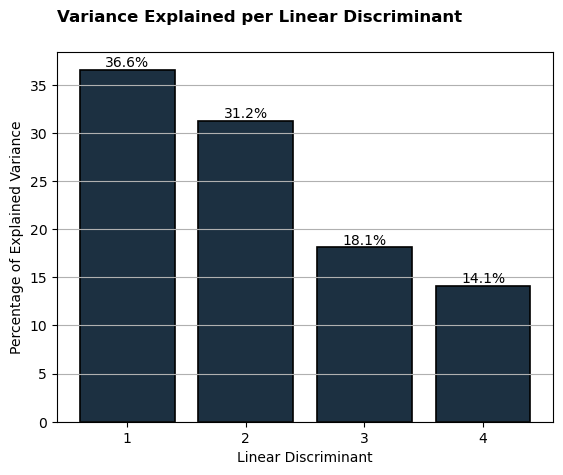

In [12]:
# LDA Explained Variance Plot
# LDA bar height = proportion of between-class variance explained
# Note: PCA bar height = total data variance != LDA bar height 

plot_y = [val * 100 for val in lda.explained_variance_ratio_]
plot_x = range(1, len(plot_y) + 1)

bars = plt.bar(plot_x, plot_y, align="center", color="#1C3041", edgecolor="#000000", linewidth=1.2)
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, yval + 0.001, f"{yval:.1f}%", ha="center", va="bottom")

plt.xlabel("Linear Discriminant")
plt.ylabel("Percentage of Explained Variance")
plt.title("Variance Explained per Linear Discriminant", loc="left", fontdict={"weight": "bold"}, y=1.06)
plt.grid(axis="y")
plt.xticks(plot_x)

plt.savefig('../src/lda.png', dpi=300, bbox_inches='tight')

plt.show()

## PCA

In [13]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

from sklearn.decomposition import PCA
pca = PCA(n_components=69)
X_pca = pca.fit_transform(X_scaled)

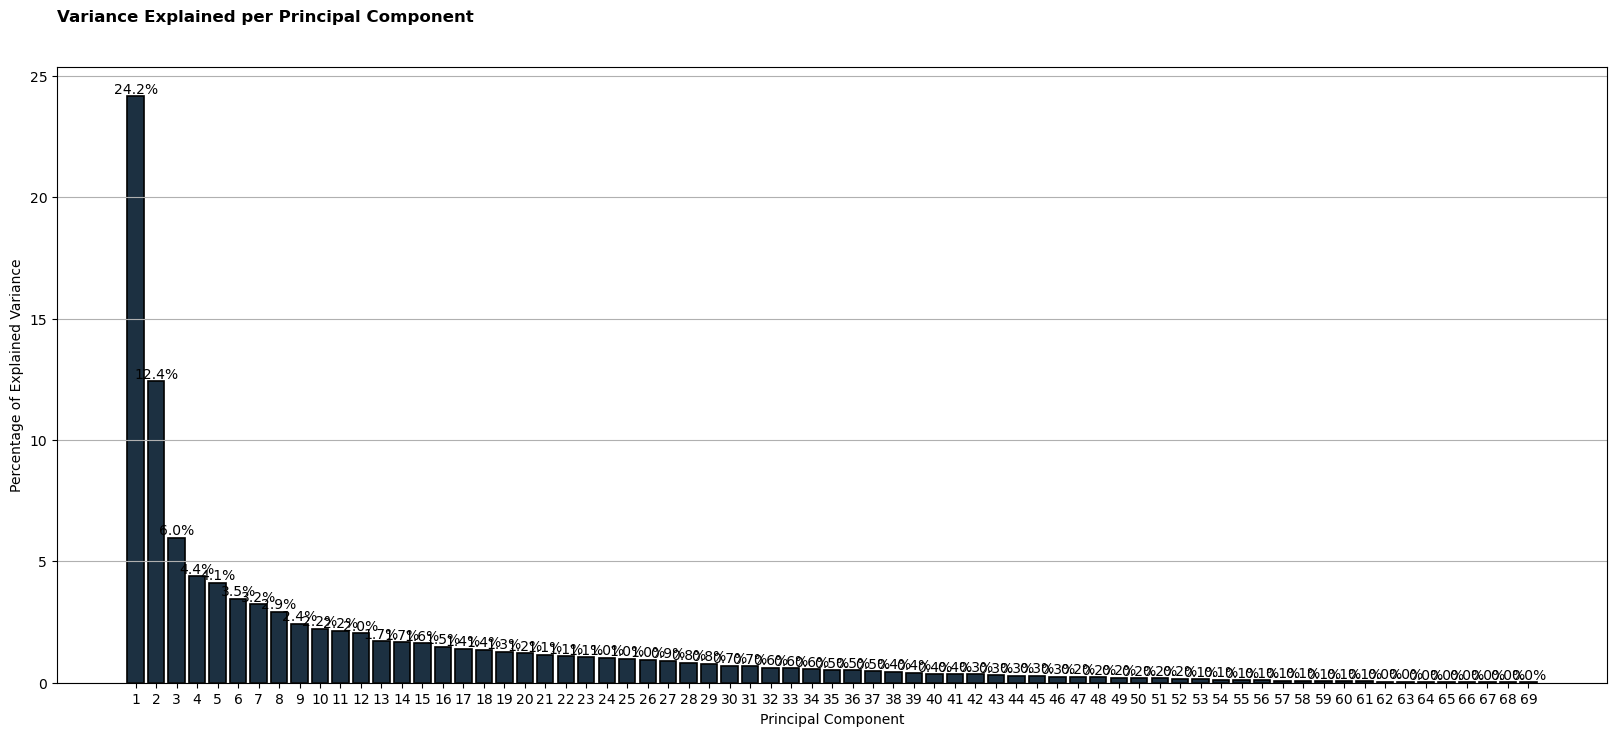

In [14]:
plot_y = [val * 100 for val in pca.explained_variance_ratio_]
plot_x = range(1, len(plot_y) + 1)

plt.figure(figsize=(20, 8))

bars = plt.bar(plot_x, plot_y, align="center", color="#1C3041", edgecolor="#000000", linewidth=1.2)
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, yval + 0.001, f"{yval:.1f}%", ha="center", va="bottom")

plt.xlabel("Principal Component")
plt.ylabel("Percentage of Explained Variance")
plt.title("Variance Explained per Principal Component", loc="left", fontdict={"weight": "bold"}, y=1.06)
plt.grid(axis="y")
plt.xticks(plot_x)

plt.savefig('../src/pca.png', dpi=300, bbox_inches='tight')

plt.show()

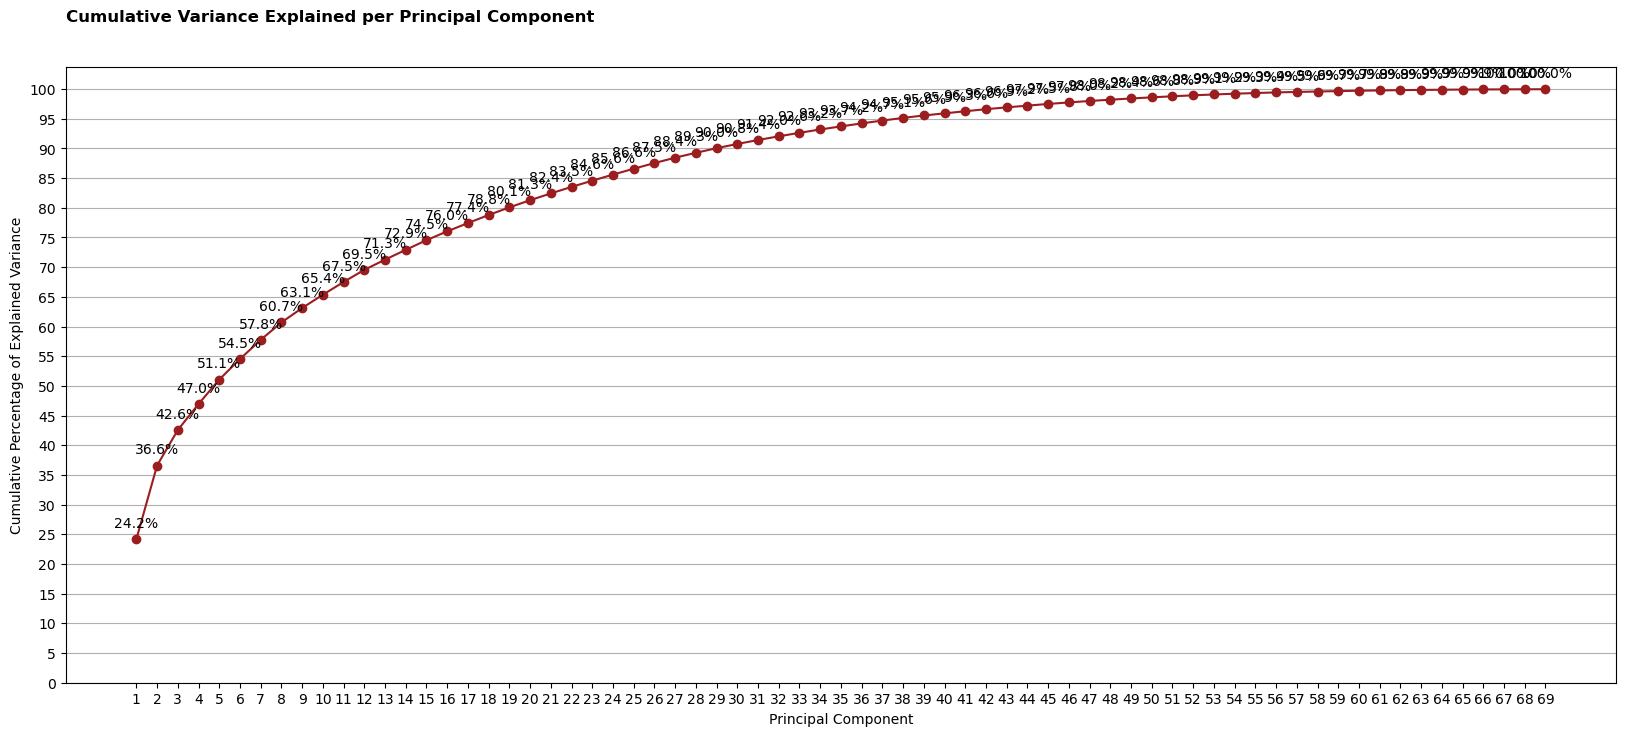

In [15]:
exp_var = [val * 100 for val in pca.explained_variance_ratio_]
plot_y = [sum(exp_var[:i+1]) for i in range(len(exp_var))]
plot_x = range(1, len(plot_y) + 1)

plt.figure(figsize=(20, 8))

plt.plot(plot_x, plot_y, marker="o", color="#9B1D20")
for x, y in zip(plot_x, plot_y):
    plt.text(x, y + 1.5, f"{y:.1f}%", ha="center", va="bottom")

plt.xlabel("Principal Component")
plt.ylabel("Cumulative Percentage of Explained Variance")
plt.title("Cumulative Variance Explained per Principal Component", loc="left", fontdict={"weight": "bold"}, y=1.06)

plt.yticks(range(0, 101, 5))
plt.grid(axis="y")
plt.xticks(plot_x)

plt.show()

In [16]:
plot_y[29]

np.float64(90.75408876367912)

In [17]:
# To see contribution of each original variable on each PC
# Larger absolute value = stronger contribution to that PC
# Direction (+/-) shows correlation direction
# Meaningful within the same PC
# Do not use this to look at importance of variables

components_df = pd.DataFrame(
    pca.components_.T,
    index=X.columns,
    columns=[f"PC{i+1}" for i in range(pca.n_components_)]
)
components_df.sort_values(by="PC1", ascending=False)

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC60,PC61,PC62,PC63,PC64,PC65,PC66,PC67,PC68,PC69
Population ages 0-14 (% of total population),0.210699,0.036520,-0.057292,-0.002781,0.039050,0.053079,0.065979,0.129992,-0.008120,-0.037545,...,0.093310,-0.000277,-0.075160,0.299631,-0.292114,0.049716,0.028810,0.021432,0.082337,0.040000
"Birth rate, crude (per 1,000 people)",0.209999,0.034186,-0.030079,-0.023986,0.068296,0.056575,0.084553,0.141199,-0.047996,-0.026910,...,-0.033682,-0.145697,-0.063713,-0.104309,0.232880,-0.063703,0.033636,-0.051398,-0.043610,-0.027446
"Fertility rate, total (births per woman)",0.200841,0.034170,-0.011441,-0.037834,0.086089,0.068121,0.094210,0.166801,-0.089332,0.018282,...,-0.026237,-0.251881,-0.051472,-0.309686,0.450588,-0.122477,0.035838,0.001858,-0.062850,-0.003435
"Vulnerable employment, female (% of female employment) (modeled ILO estimate)",0.196228,0.058110,0.034355,-0.090369,0.020428,-0.106265,-0.057834,-0.035687,0.019247,-0.060873,...,0.030712,-0.115857,-0.098345,-0.309541,-0.418468,-0.374055,-0.023152,-0.066682,-0.066728,-0.083087
"Mortality rate, under-5 (per 1,000 live births)",0.196191,0.044420,0.031045,-0.057739,0.071824,0.095692,0.014875,0.076648,-0.013246,0.069640,...,0.094841,0.018067,-0.052430,0.024042,-0.099269,0.020162,-0.003289,0.114652,-0.012502,-0.054694
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Access to electricity (% of population),-0.180288,-0.043193,-0.084411,0.088853,-0.150001,-0.029778,-0.036236,-0.062341,0.031743,-0.012016,...,0.089230,-0.144788,-0.093404,0.044300,0.068545,0.032052,-0.008198,0.018859,0.029936,0.031258
Fixed broadband subscriptions (per 100 people),-0.187144,-0.009117,0.122135,-0.046138,0.042535,-0.029126,0.063481,0.006212,-0.129977,0.003965,...,0.083697,0.068220,-0.003084,0.037166,-0.010175,-0.031771,0.020932,0.021093,0.012176,-0.028263
"Life expectancy at birth, male (years)",-0.197640,-0.036318,-0.026147,-0.033727,0.000554,-0.116626,-0.004986,0.070119,-0.104446,-0.167405,...,0.016135,-0.080008,-0.053745,0.051579,-0.080611,0.040609,-0.009197,-0.566663,0.150781,0.266726
"Life expectancy at birth, total (years)",-0.202628,-0.038455,-0.011693,-0.021013,-0.011528,-0.110264,-0.008761,0.044246,-0.091554,-0.161330,...,0.011760,-0.066212,-0.030478,0.070288,-0.064418,-0.016951,0.027030,0.015372,0.010772,-0.002471


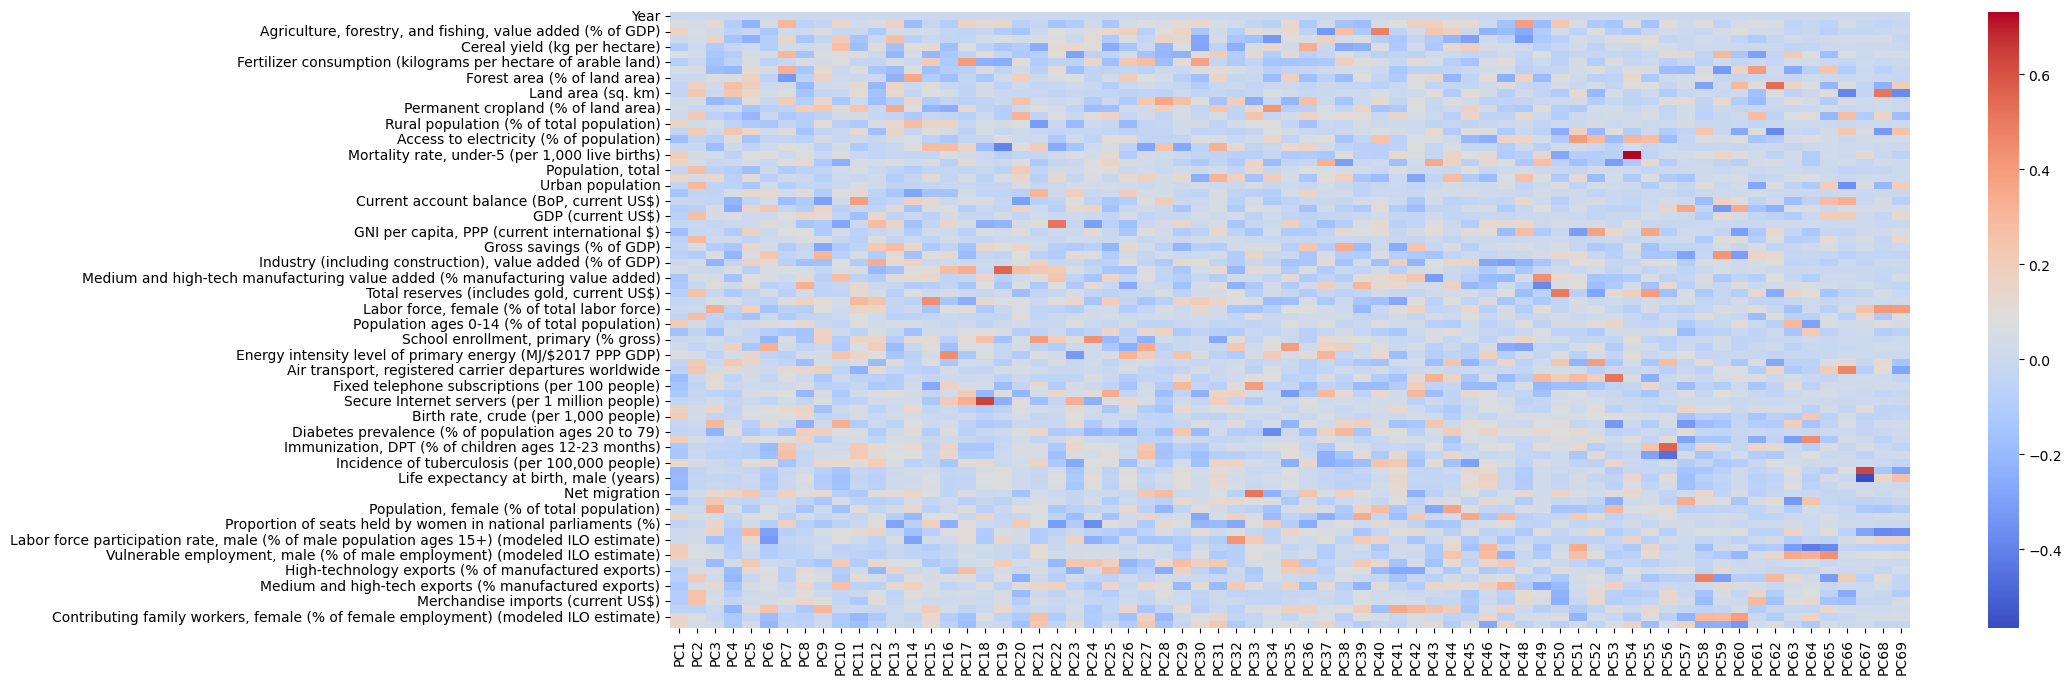

In [18]:
plt.figure(figsize=(20,8))
sns.heatmap(components_df,cmap='coolwarm')
plt.show()

# y axis = each variable
# The result shows that each variable contributes to each principal component